In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from Analysis import (
    SpatiotemporalAnalysis,demodulate
)
from matplotlib.lines import Line2D

Fogi timing

In [2]:
cd = "CDK183"
ctrl_path = f"D:\\K_Sunada\\result\\{cd}\\"

result_dict_tx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-07-22", acquire_time="101228", duration=1500),
    data_ph1 = dict(target_freq=9.38, date="2025-07-22", acquire_time="101338", duration=1500),
    data_ph2 = dict(target_freq=9.38, date="2025-07-22", acquire_time="101446", duration=1500),
    data_ph3 = dict(target_freq=9.38, date="2025-07-22", acquire_time="101555", duration=1500),
)

result_dict_rx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-07-22", acquire_time="104611", duration=1500),
    data_ph1 = dict(target_freq=9.38, date="2025-07-22", acquire_time="104718", duration=1500),
    data_ph2 = dict(target_freq=9.38, date="2025-07-22", acquire_time="104823", duration=1500),
    data_ph3 = dict(target_freq=9.38, date="2025-07-22", acquire_time="104930", duration=1500),
)

delay -2.266666666666694
delay 38.53333333333336
delay 63.46666666666675
delay 23.8


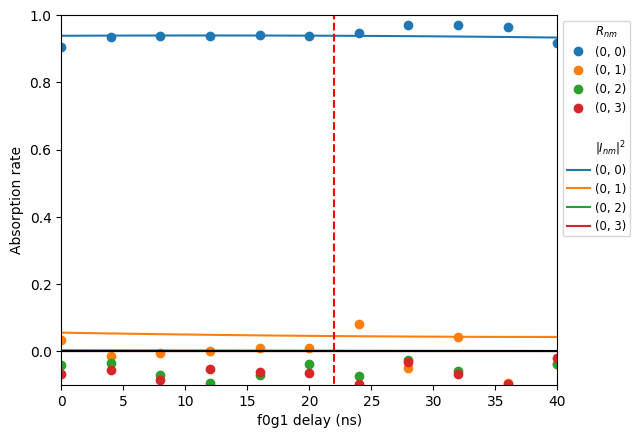

In [3]:
header = "D:/K_sunada/result/CDY183/"
ph0_fo0 = "/2025-07-22/2025-07-22T110249_f7c23c9e-j1_JPA_comm_timing"
ph0_fo1 = "/2025-07-22/2025-07-22T113417_5d2f3e35-j1_JPA_comm_timing"
ph0_fo2 = "/2025-07-22/2025-07-22T120548_c4605a28-j1_JPA_comm_timing"
ph0_fo3 = "/2025-07-22/2025-07-22T123717_2a596d27-j1_JPA_comm_timing"

num_of_ph_amp = 1
num_of_fogi_timing = 11
f_if = (9.5-9.38)*1e9

acquisition_00 = SpatiotemporalAnalysis(ctrl_path, ph0_fo0, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_01 = SpatiotemporalAnalysis(ctrl_path, ph0_fo1, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_02 = SpatiotemporalAnalysis(ctrl_path, ph0_fo2, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_03 = SpatiotemporalAnalysis(ctrl_path, ph0_fo3, ctrl_path, result_dict_tx['data_ph0'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots()
acquisition_00.plot_results(ax, label="ph_0 & fogi_0", color="tab:blue", fitting=True, init_fit=True)
acquisition_01.plot_results(ax, label="ph_0 & fogi_1", color="tab:orange", fitting=True, init_fit=True)
acquisition_02.plot_results(ax, label="ph_0 & fogi_2", color="tab:green", fitting=True, init_fit=True)
acquisition_03.plot_results(ax, label="ph_0 & fogi_3", color="tab:red", fitting=True, init_fit=True)

ax.set_ylim(-0.10, 1)
ax.set_xlim(0, 40)
ax.vlines(22, -10, 100, color="r", linestyle="dashed")
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(0, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(0, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(0, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"),
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(0, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(0, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(0, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )
plt.hlines(0, 0, 40, "black")
plt.xlabel("f0g1 delay (ns)")
plt.ylabel("Absorption rate")
# plt.savefig('abs_timing.png', bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'E_a')

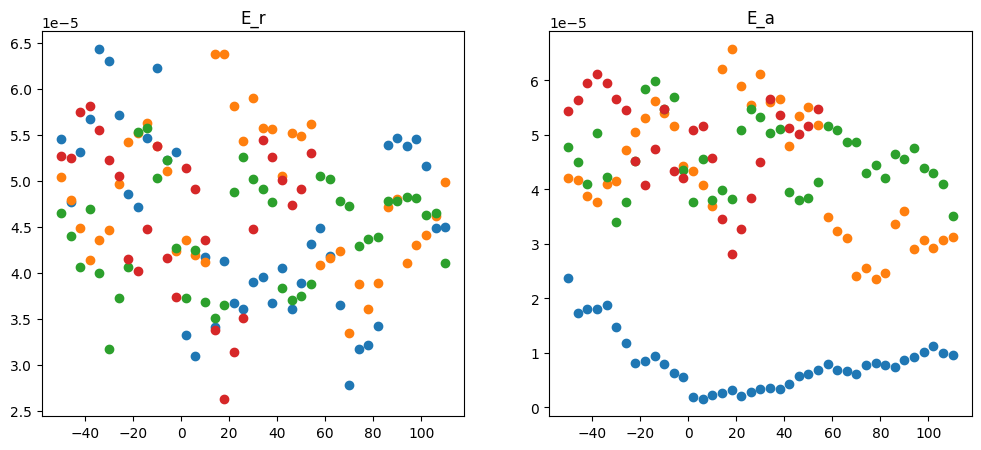

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
acquisition_00.plot_er_ea(ax, label="ph_0 & fogi_0", color="tab:blue")
acquisition_01.plot_er_ea(ax, label="ph_0 & fogi_1", color="tab:orange")
acquisition_02.plot_er_ea(ax, label="ph_0 & fogi_2", color="tab:green")
acquisition_03.plot_er_ea(ax, label="ph_0 & fogi_3", color="tab:red")

ax[0].set_title("E_r", fontsize="large")
ax[1].set_title("E_a", fontsize="large")

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


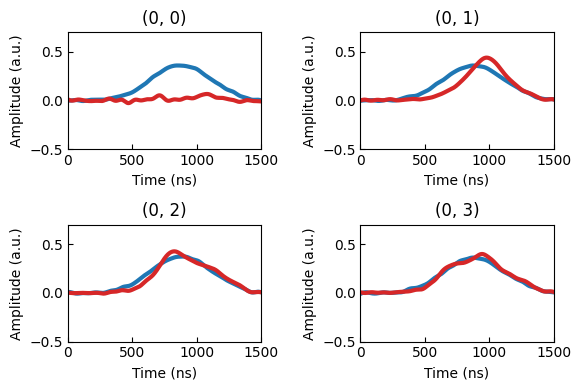

In [9]:
ph_amp = 0
fogi_freq = 8
fig, axs = plt.subplots(2, 2, figsize=(6, 4) ) 
acquisition_00.plot_waveform(ax=axs[0, 0], title="(0, 0)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_01.plot_waveform(ax=axs[0, 1], title="(0, 1)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_02.plot_waveform(ax=axs[1, 0], title="(0, 2)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_03.plot_waveform(ax=axs[1, 1], title="(0, 3)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)

plt.tight_layout()
plt.show()


phototn 1

delay 134.8666666666669
delay 37.400000000000034
delay 48.733333333333384
delay 53.26666666666672


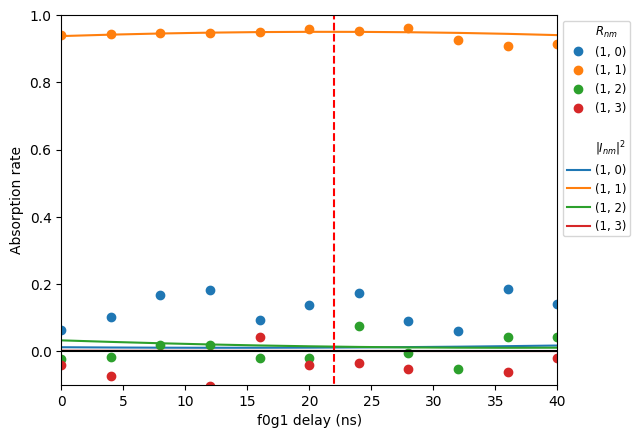

In [5]:
ph1_fo0 = "/2025-07-22/2025-07-22T130847_90efac8b-j1_JPA_comm_timing"
ph1_fo1 = "/2025-07-22/2025-07-22T134017_f799c07a-j1_JPA_comm_timing"
ph1_fo2 = "/2025-07-22/2025-07-22T141149_5f1db43e-j1_JPA_comm_timing"
ph1_fo3 = "/2025-07-22/2025-07-22T144320_c68575c6-j1_JPA_comm_timing"

acquisition_10 = SpatiotemporalAnalysis(ctrl_path, ph1_fo0, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_11 = SpatiotemporalAnalysis(ctrl_path, ph1_fo1, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_12 = SpatiotemporalAnalysis(ctrl_path, ph1_fo2, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_13 = SpatiotemporalAnalysis(ctrl_path, ph1_fo3, ctrl_path, result_dict_tx['data_ph1'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots()
acquisition_10.plot_results(ax, label="ph_1 & fogi_0", color="tab:blue", fitting=True, init_fit=True)
acquisition_11.plot_results(ax, label="ph_1 & fogi_1", color="tab:orange", fitting=True, init_fit=True)
acquisition_12.plot_results(ax, label="ph_1 & fogi_2", color="tab:green", fitting=True, init_fit=True)
acquisition_13.plot_results(ax, label="ph_1 & fogi_3", color="tab:red", fitting=True, init_fit=True)

ax.set_ylim(-0.1, 1)
ax.set_xlim(0, 40)
plt.vlines(22, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"), 
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(1, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(1, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(1, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(1, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"), 
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(1, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(1, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(1, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(1, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )
plt.hlines(0, 0, 40, "black")
plt.xlabel("f0g1 delay (ns)")
plt.ylabel("Absorption rate")
# plt.savefig('abs_timing.png', bbox_inches='tight')
plt.show()

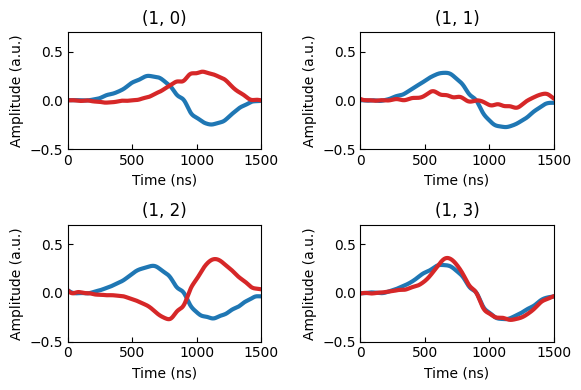

In [10]:
ph_amp = 0
fogi_freq = 8
fig, axs = plt.subplots(2, 2, figsize=(6, 4) ) 
acquisition_10.plot_waveform(ax=axs[0, 0], title="(1, 0)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_11.plot_waveform(ax=axs[0, 1], title="(1, 1)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_12.plot_waveform(ax=axs[1, 0], title="(1, 2)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_13.plot_waveform(ax=axs[1, 1], title="(1, 3)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)

plt.tight_layout()
plt.show()


phototn 2

delay 30.033333333333346
delay 82.73333333333345
delay -5.666666666666698
delay 30.033333333333346


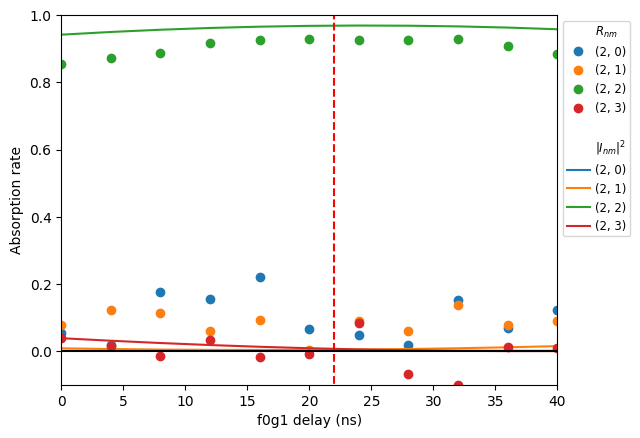

In [6]:
ph2_fo0 = "/2025-07-22/2025-07-22T151453_2e70cbae-j1_JPA_comm_timing"
ph2_fo1 = "/2025-07-22/2025-07-22T154625_968513c0-j1_JPA_comm_timing"
ph2_fo2 = "/2025-07-22/2025-07-22T161801_0094b4c0-j1_JPA_comm_timing"
ph2_fo3 = "/2025-07-22/2025-07-22T164936_69cccf68-j1_JPA_comm_timing"

acquisition_20 = SpatiotemporalAnalysis(ctrl_path, ph2_fo0, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_21 = SpatiotemporalAnalysis(ctrl_path, ph2_fo1, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_22 = SpatiotemporalAnalysis(ctrl_path, ph2_fo2, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_23 = SpatiotemporalAnalysis(ctrl_path, ph2_fo3, ctrl_path, result_dict_tx['data_ph2'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots()
acquisition_20.plot_results(ax, label="ph_2 & fogi_0", color="tab:blue", fitting=True, init_fit=True)
acquisition_21.plot_results(ax, label="ph_2 & fogi_1", color="tab:orange", fitting=True, init_fit=True)
acquisition_22.plot_results(ax, label="ph_2 & fogi_2", color="tab:green", fitting=True, init_fit=True)
acquisition_23.plot_results(ax, label="ph_2 & fogi_3", color="tab:red", fitting=True, init_fit=True)

ax.set_ylim(-0.10, 1)
ax.set_xlim(0, 40)
plt.vlines(22, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(2, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(2, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(2, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(2, 3)"),
    Line2D([0], [0], color="none", marker="", label=""), 
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"), 
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(2, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(2, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(2, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(2, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3)
plt.hlines(0, 0, 40, "black")
plt.xlabel("f0g1 delay (ns)")
plt.ylabel("Absorption rate")
plt.show()

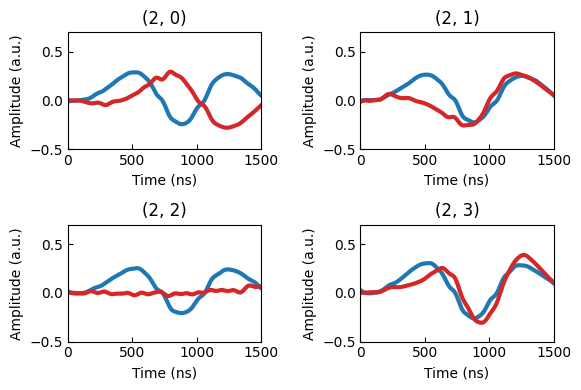

In [11]:
ph_amp = 0
fogi_freq = 8
fig, axs = plt.subplots(2, 2, figsize=(6, 4) ) 
acquisition_20.plot_waveform(ax=axs[0, 0], title="(2, 0)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_21.plot_waveform(ax=axs[0, 1], title="(2, 1)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_22.plot_waveform(ax=axs[1, 0], title="(2, 2)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_23.plot_waveform(ax=axs[1, 1], title="(2, 3)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)

plt.tight_layout()
plt.show()


phototn 3

delay -45.333333333333414
delay 149.0333333333336
delay -27.200000000000056
delay -3.966666666666696


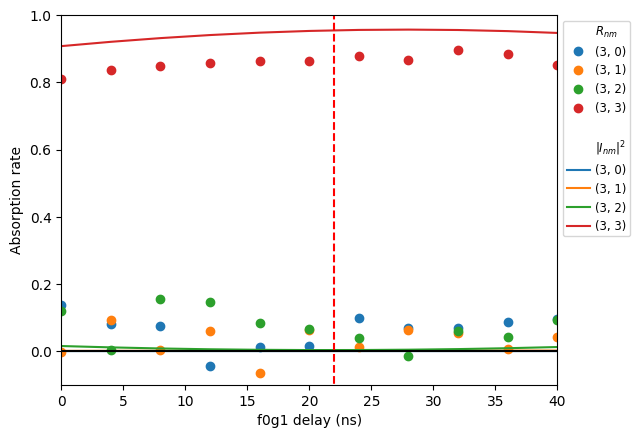

In [7]:
ph3_fo0 = "/2025-07-22/2025-07-22T172110_d2a95717-j1_JPA_comm_timing"
ph3_fo1 = "/2025-07-22/2025-07-22T175247_3d7855e2-j1_JPA_comm_timing"
ph3_fo2 = "/2025-07-22/2025-07-22T182424_a84928c8-j1_JPA_comm_timing"
ph3_fo3 = "/2025-07-22/2025-07-22T185602_13b52410-j1_JPA_comm_timing"

acquisition_30 = SpatiotemporalAnalysis(ctrl_path, ph3_fo0, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_31 = SpatiotemporalAnalysis(ctrl_path, ph3_fo1, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_32 = SpatiotemporalAnalysis(ctrl_path, ph3_fo2, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_33 = SpatiotemporalAnalysis(ctrl_path, ph3_fo3, ctrl_path, result_dict_tx['data_ph3'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)

fig, ax = plt.subplots()
acquisition_30.plot_results(ax, label="ph_3 & fogi_0", color="tab:blue", fitting=True, init_fit=True)
acquisition_31.plot_results(ax, label="ph_3 & fogi_1", color="tab:orange", fitting=True, init_fit=True)
acquisition_32.plot_results(ax, label="ph_3 & fogi_2", color="tab:green", fitting=True, init_fit=True)
acquisition_33.plot_results(ax, label="ph_3 & fogi_3", color="tab:red", fitting=True, init_fit=True)

ax.set_ylim(-0.10, 1)
ax.set_xlim(0, 40)
plt.vlines(22, -10, 100, linestyles='--',colors='red')
custom_legend = [
    Line2D([0], [0], color="none", marker="o", linestyle="None", label="$R_{nm}$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(3, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(3, 1)"),
    Line2D([0], [0], color="tab:green", marker="o", linestyle="None",label="(3, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(3, 3)"),
    Line2D([0], [0], color="none", marker="", label=""),
    Line2D([0], [0], color="none", linestyle="-", label="$|I_{nm}|^2$"),
    Line2D([0], [0], color="tab:blue", linestyle="-", label="(3, 0)"),
    Line2D([0], [0], color="tab:orange", linestyle="-", label="(3, 1)"),
    Line2D([0], [0], color="tab:green", linestyle="-", label="(3, 2)"),
    Line2D([0], [0], color="tab:red", linestyle="-", label="(3, 3)"),
]
plt.legend(handles=custom_legend, loc="upper left", bbox_to_anchor=(1., 1),ncol=1,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )
plt.hlines(0, -50, 100, "black")
plt.xlabel("f0g1 delay (ns)")
plt.ylabel("Absorption rate")
plt.show()

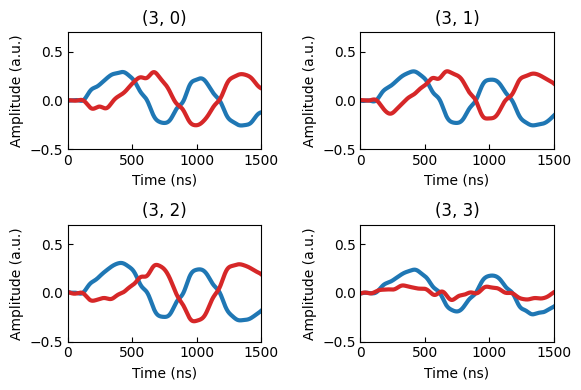

In [12]:
ph_amp = 0
fogi_freq = 8
fig, axs = plt.subplots(2, 2, figsize=(6, 4) ) 
acquisition_30.plot_waveform(ax=axs[0, 0], title="(3, 0)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_31.plot_waveform(ax=axs[0, 1], title="(3, 1)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_32.plot_waveform(ax=axs[1, 0], title="(3, 2)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)
acquisition_33.plot_waveform(ax=axs[1, 1], title="(3, 3)", ph_amp_idx=ph_amp, fogi_freq_idx=fogi_freq)

plt.tight_layout()
plt.show()


delay 7.933333333333318
delay 22.666666666666668
delay 20.966666666666665
delay 23.8
delay 7.933333333333318
delay 35.13333333333336
delay 119.00000000000018
delay 27.20000000000001


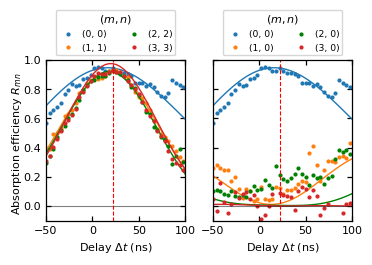

In [17]:
num_of_ph_amp = 1
num_of_fogi_timing = 51
f_if = (9.5-9.38)*1e9

fig, ax = plt.subplots(1, 2, figsize=(3.6, 2.2))
acquisition_00.plot_results(ax[0], label="ph_0 & fogi_0", color="tab:blue", fitting=True, init_fit=True)
acquisition_11.plot_results(ax[0], label="ph_1 & fogi_1", color="tab:orange", fitting=True, init_fit=True)
acquisition_22.plot_results(ax[0], label="ph_2 & fogi_2", color="green", fitting=True, init_fit=True)
acquisition_33.plot_results(ax[0], label="ph_3 & fogi_3", color="tab:red", fitting=True, init_fit=True)

acquisition_00.plot_results(ax[1], label="ph_0 & fogi_0", color="tab:blue", fitting=True, init_fit=True)
acquisition_10.plot_results(ax[1], label="ph_1 & fogi_0", color="tab:orange", fitting=True, init_fit=True)
acquisition_20.plot_results(ax[1], label="ph_2 & fogi_0", color="green", fitting=True, init_fit=True)
acquisition_30.plot_results(ax[1], label="ph_3 & fogi_0", color="tab:red", fitting=True, init_fit=True)

custom_legend0 = [
    # Line2D([0], [0], color="none", marker="o", linestyle="None", label="$(m, n)$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(1, 1)"),
    Line2D([0], [0], color="green", marker="o", linestyle="None",label="(2, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(3, 3)"),
]
ax[0].legend(handles=custom_legend0, title=r"$(m, n)$", loc="lower center", bbox_to_anchor=(0.5, 1),ncol=2,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )

custom_legend1 = [
    # Line2D([0], [0], color="none", marker="o", linestyle="None", label="$(m, n)$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(1, 0)"),
    Line2D([0], [0], color="green", marker="o", linestyle="None",label="(2, 0)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(3, 0)"),
]
ax[1].legend(handles=custom_legend1, title=r"$(m, n)$", loc="lower center", bbox_to_anchor=(0.5, 1),ncol=2,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )

ax[0].set_ylim(-0.1, 1)
ax[0].set_xlim(-50, 100)
ax[0].set_xlabel(r"Delay $\Delta t$ (ns)")
ax[1].set_ylim(-0.1, 1)
ax[1].set_xlim(-50, 100)
ax[1].set_xlabel(r"Delay $\Delta t$ (ns)")

fig.text(0.02, 0.55, r"Absorption efficiency $R_{mn}$", va='center', rotation='vertical')
for a in ax:
    a.tick_params(axis="both", direction="in")
    a.axhline(0, color='black', linewidth=0.8, alpha=0.5, linestyle='-')
    a.axvline(22, color='red', linewidth=0.8, linestyle="dashed") 
ax[1].tick_params(labelleft=False) 
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.subplots_adjust(left=0.12, right=0.97, top=0.93, bottom=0.2, wspace=0.2)
# plt.savefig('Fig3_a1.pdf', bbox_inches='tight')
plt.show()

delay 7.933333333333318
delay 22.666666666666668
delay 20.966666666666665
delay 23.8
delay 51.00000000000006
delay 22.666666666666668
delay 24.933333333333334
delay 80.46666666666678


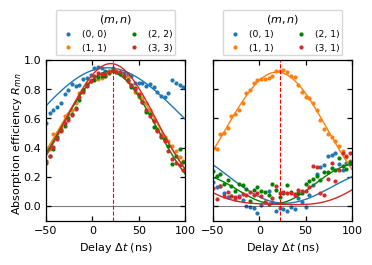

In [ ]:
num_of_ph_amp = 1
num_of_fogi_timing = 51
f_if = (9.5-9.38)*1e9

fig, ax = plt.subplots(1, 2, figsize=(3.6, 2.2))
acquisition_00.plot_results(ax[0], label="ph_0 & fogi_0", color="tab:blue", fitting=True, init_fit=True)
acquisition_11.plot_results(ax[0], label="ph_1 & fogi_1", color="tab:orange", fitting=True, init_fit=True)
acquisition_22.plot_results(ax[0], label="ph_2 & fogi_2", color="green", fitting=True, init_fit=True)
acquisition_33.plot_results(ax[0], label="ph_3 & fogi_3", color="tab:red", fitting=True, init_fit=True)

acquisition_01.plot_results(ax[1], label="ph_0 & fogi_1", color="tab:blue", fitting=True, init_fit=True)
acquisition_11.plot_results(ax[1], label="ph_1 & fogi_1", color="tab:orange", fitting=True, init_fit=True)
acquisition_21.plot_results(ax[1], label="ph_2 & fogi_1", color="green", fitting=True, init_fit=True)
acquisition_31.plot_results(ax[1], label="ph_3 & fogi_1", color="tab:red", fitting=True, init_fit=True)

custom_legend0 = [
    # Line2D([0], [0], color="none", marker="o", linestyle="None", label="$(m, n)$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(0, 0)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(1, 1)"),
    Line2D([0], [0], color="green", marker="o", linestyle="None",label="(2, 2)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(3, 3)"),
]
ax[0].legend(handles=custom_legend0, title=r"$(m, n)$", loc="lower center", bbox_to_anchor=(0.5, 1),ncol=2,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )

custom_legend1 = [
    # Line2D([0], [0], color="none", marker="o", linestyle="None", label="$(m, n)$"),
    Line2D([0], [0], color="tab:blue", marker="o", linestyle="None",label="(0, 1)"),
    Line2D([0], [0], color="tab:orange", marker="o", linestyle="None",label="(1, 1)"),
    Line2D([0], [0], color="green", marker="o", linestyle="None",label="(2, 1)"),
    Line2D([0], [0], color="tab:red", marker="o", linestyle="None",label="(3, 1)"),
]
ax[1].legend(handles=custom_legend1, title=r"$(m, n)$", loc="lower center", bbox_to_anchor=(0.5, 1),ncol=2,  fontsize="small", 
           handletextpad=0.5, borderpad=0.3 )

ax[0].set_ylim(-0.1, 1)
ax[0].set_xlim(-50, 100)
ax[0].set_xlabel(r"Delay $\Delta t$ (ns)")
ax[1].set_ylim(-0.1, 1)
ax[1].set_xlim(-50, 100)
ax[1].set_xlabel(r"Delay $\Delta t$ (ns)")

fig.text(0.02, 0.55, r"Absorption efficiency $R_{mn}$", va='center', rotation='vertical')
for a in ax:
    a.tick_params(axis="both", direction="in")
    a.axhline(0, color='black', linewidth=0.8, alpha=0.5, linestyle='-')
    a.axvline(22, color='red', linewidth=0.8, linestyle="dashed") 
ax[1].tick_params(labelleft=False) 
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.subplots_adjust(left=0.12, right=0.97, top=0.93, bottom=0.2, wspace=0.2)
# plt.savefig('Fig3_a1.pdf', bbox_inches='tight')
plt.show()

## analysis

In [8]:

rates_00 = acquisition_00.get_rates()["rates"]
rates_11 = acquisition_11.get_rates()["rates"]
rates_22 = acquisition_22.get_rates()["rates"]
rates_33 = acquisition_33.get_rates()["rates"]

length = len(rates_00)

total_rates = [
    rates_00[i] + rates_11[i] + rates_22[i] + rates_33[i]
    for i in range(length)
]

max_i = max(range(length), key=lambda i: total_rates[i])
max_value = total_rates[max_i]

print(f"i: {max_i}")
print(f"sum: {max_value}")


i: 8
sum: 372.5962368676592


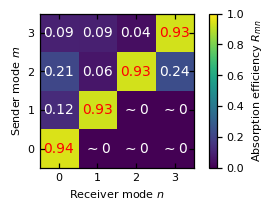

373.19045113618654


In [16]:
fig, ax = plt.subplots(figsize=(4, 2))
i = 18
data = np.array([[acquisition_30.get_rates()["rates"][i], acquisition_31.get_rates()["rates"][i], acquisition_32.get_rates()["rates"][i], acquisition_33.get_rates()["rates"][i]],
                [acquisition_20.get_rates()["rates"][i], acquisition_21.get_rates()["rates"][i], acquisition_22.get_rates()["rates"][i], acquisition_23.get_rates()["rates"][i]],
                [acquisition_10.get_rates()["rates"][i], acquisition_11.get_rates()["rates"][i], acquisition_12.get_rates()["rates"][i], acquisition_13.get_rates()["rates"][i]],
                [acquisition_00.get_rates()["rates"][i], acquisition_01.get_rates()["rates"][i], acquisition_02.get_rates()["rates"][i], acquisition_03.get_rates()["rates"][i]]])
SpatiotemporalAnalysis.plot_absorption_rate_matrix(data, ax)

# plt.close()
# plt.imshow(plt.imread("abs_rate.png"))
ax.tick_params(axis="both", direction="in")
ax.tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.savefig('Fig3_b1.pdf', bbox_inches='tight')
# plt.savefig('Fig3_b.png', bbox_inches='tight')
plt.show()
print(acquisition_00.get_rates()["rates"][i]+acquisition_11.get_rates()["rates"][i]
      +acquisition_22.get_rates()["rates"][i]+acquisition_33.get_rates()["rates"][i])

In [14]:
M = 4  
acquisitions = [[acquisition_00, acquisition_01, acquisition_02, acquisition_03],
                [acquisition_10, acquisition_11, acquisition_12, acquisition_13],
                [acquisition_20, acquisition_21, acquisition_22, acquisition_23],
                [acquisition_30, acquisition_31, acquisition_32, acquisition_33]]

R = np.zeros((M, M))
index = 18

for m in range(M):
    for n in range(M):
        R[m, n] = acquisitions[m][n].get_rates()["rates"][index]*0.01

separability = 0.98
selectivities = []
for m in range(M):
    S_m = separability * R[m, m]
    selectivities.append(S_m)

S_total = np.mean(selectivities)

print("Mode-wise selectivity:", selectivities)
print("Total selectivity:", S_total)

Mode-wise selectivity: [0.9251701051659501, 0.9085980029837151, 0.9112542569804654, 0.9122440560044974]
Total selectivity: 0.914316605283657


orthogonality

In [17]:
def overlap(func1, func2):
    i = 0
    for t in range(len(func1)):
        i += func1[t] * np.conjugate(func2[t])
    return np.abs(i)

In [18]:
def waveform_complex(data):
    time = data.get_results()["time"][ph_amp][fogi_freq]
    waveform = data.get_results()["waveform"][ph_amp][fogi_freq]
    phase = np.angle(demodulate(time, waveform, f_if*1e-9))
    waveform_complex = waveform * np.exp(-1j*phase)
    
    waveform_wo_fogi = data.get_results()["waveform_zero_fogi"][ph_amp][fogi_freq]
    phase_wo_fogi = np.angle(demodulate(time, waveform_wo_fogi, f_if*1e-9))
    waveform_complex_wo_fogi = waveform_wo_fogi * np.exp(-1j*phase_wo_fogi)
    
    return time, waveform_complex, waveform_complex_wo_fogi

In [19]:
from scipy import signal
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

In [20]:
def waveform_envelope(data):
    time = data.get_results()["time"][ph_amp][fogi_freq]

    env =  data.get_results()["y_absorbed_envs"][ph_amp][fogi_freq]
    env_wo_fogi = data.get_results()["y_base_envs"][ph_amp][fogi_freq]
    return time, env, env_wo_fogi

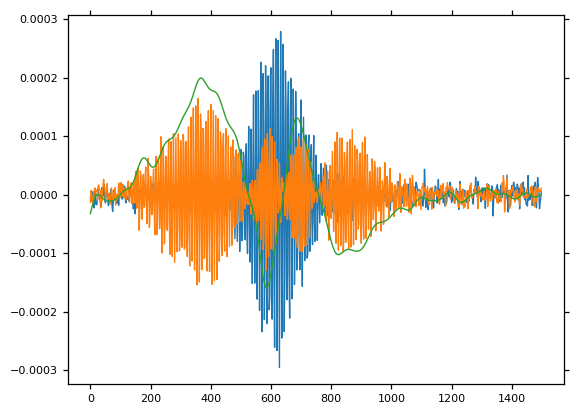

In [21]:
plt.plot(waveform_complex(acquisition_00)[0], waveform_complex(acquisition_00)[2].real )
plt.plot(waveform_complex(acquisition_00)[0], waveform_complex(acquisition_30)[2].real )
plt.plot(waveform_envelope(acquisition_00)[0], waveform_envelope(acquisition_30)[2].real )

In [22]:
from datataking import search_datadict_miyamura
from Analysis import start_stop, fourier_tr_padding, lowpass


In [23]:
def process_ctrl_pulse(datadict):
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, 1500)


    phase = np.angle(demodulate(time, waveform, f_if*1e-9))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*f_if*1e-9*time),
                        0.01, 0.03, 0.1, 90) * np.exp(-1j*phase)

    norm=np.sum(2*np.abs(signal)**2)**0.5
    return time, signal#/norm

In [24]:
from scipy.ndimage import shift as nd_shift

def roll_with_interpolation(array, shift):
    return nd_shift(array, shift=shift, mode='constant', cval=0.0)


In [25]:
def analyze_waveforms_t(datasets, passing_band= 0.01, wofogi=True, projection=False, rx_mode=0):
    fig, axes = plt.subplots(2, 2, figsize=(4.2, 2.2), sharex=True, sharey=True)
    axes = axes.flatten()

    fig_fft, axes_fft = plt.subplots(2, 2, figsize=(4.2, 2.2), sharex=True, sharey=True)
    axes_fft = axes_fft.flatten()

    fig_rcoeff, ax_r = plt.subplots(figsize=(3.5, 2.5))

    for i, (k, v) in enumerate(datasets.items()):
        if i >= 4:
            break

        ax = axes[i]
        target_freq = v["target_freq"]
        readout_lo_freq = 9.47

        time = waveform_complex(acquisition_00)[0]
        waveform_wo_fogi = v["waveform"].get_results()["waveform_zero_fogi"][ph_amp][fogi_freq]
        waveform_w_fogi = v["waveform"].get_results()["waveform"][ph_amp][fogi_freq]
        if wofogi:
            waveform = waveform_wo_fogi
        else:
            waveform = waveform_w_fogi

        xfft_wo_fogi, fourier_wo_fogi = fourier_tr_padding(time, waveform_wo_fogi)
        xfft_wo_fogi, fourier_wo_fogi = start_stop(xfft_wo_fogi, fourier_wo_fogi, xfft_wo_fogi[0], 0)

        phase_wo_fogi = np.angle(demodulate(time, waveform_wo_fogi, readout_lo_freq - target_freq))
        lpf_wo_fogi = 2 * lowpass(
            time, waveform_wo_fogi * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
            passing_band, 0.03, 0.1, 90
        ) 
        signal_wo_fogi =lpf_wo_fogi* np.exp(-1j * phase_wo_fogi)
        ax.plot(time, 2000 * waveform_wo_fogi, "tab:blue", lw=0.5, alpha=0.5)
        ax.plot(time, 2000 * signal_wo_fogi, "tab:blue", lw=2, alpha=1, label="reflected (w/o fogi) waveform")

        xfft, fourier = fourier_tr_padding(time, waveform)
        xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)

        phase = np.angle(demodulate(time, waveform, readout_lo_freq - target_freq))
        lpf = 2 * lowpass(
            time, waveform * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
            passing_band, 0.03, 0.1, 90
        ) 
        signal =lpf* np.exp(-1j * phase)
        ax.plot(time, 2000 * waveform, "tab:orange", lw=0.5, alpha=0.5)
        ax.plot(time, 2000 * signal, "tab:orange", lw=2, alpha=1, label="rejected (w/ fogi) waveform")
        ax.grid(True)
        if projection:
            _, ctrl_pulse_tx_dd = search_datadict_miyamura(ctrl_path, result_dict_tx[f"data_ph{i}"]["date"], acquire_time=result_dict_tx[f"data_ph{i}"]["acquire_time"])
            time, xi_m = process_ctrl_pulse(ctrl_pulse_tx_dd)
            _, ctrl_pulse_rx_dd = search_datadict_miyamura(ctrl_path, result_dict_rx[f"data_ph{rx_mode}"]["date"], acquire_time=result_dict_rx[f"data_ph{rx_mode}"]["acquire_time"])
            time, xi_n = process_ctrl_pulse(ctrl_pulse_rx_dd)
            xi_n = roll_with_interpolation(xi_n[::-1], -250)
            inner = overlap(xi_m, xi_n)
            norm_sq = np.abs(overlap(xi_n, xi_n))
            ax.plot(time, 2000 * xi_m)
            ax.plot(time, 2000 * xi_n)
            xi_res = xi_m - (inner / norm_sq) * xi_n
            ax.plot(time, 2000 * xi_res, linestyle='--', color='red')

        ax_fft = axes_fft[i]
        ax_fft.set_xlim(target_freq-0.025, target_freq+0.025)
        ax_fft.plot(xfft_wo_fogi+readout_lo_freq, np.abs(fourier_wo_fogi), color="tab:blue", lw=1.5, alpha=1, label="reflected (w/o fogi) waveform")
        ax_fft.plot(xfft+readout_lo_freq, np.abs(fourier), color="tab:orange", lw=1.5, alpha=1, label="rejected (w/ fogi) waveform")

        # ax_fft.set_xlim(-0.2, 0.2)
        # ax_fft.set_title(f"FFT Spectrum {i}")
        ax.label_outer()
        ax.set_xlim(0, 1500)
        if i == 0:
            fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=1)
            fig_fft.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=1)
        if i in [2, 3]:
            ax.set_xlabel("Time (ns)")
            ax_fft.set_xlabel("Frequency (GHz)")

        eps = 1e-12
        rcoeff = fourier / (fourier_wo_fogi + eps)
        ax_r.plot(xfft+readout_lo_freq, np.abs(rcoeff), lw=1.5, label=f"mode {i}")
            
    fig.text(0.04, 0.5, "Amplitude (a.u.)", va="center", rotation="vertical")
    fig_fft.text(0.04, 0.5, "Amplitude (a.u.)", va="center", rotation="vertical")

    ax_r.set_xlim(target_freq-0.01, target_freq+0.01)
    ax_r.set_ylim(-0.1, 5)
    ax_r.set_xlabel("Frequency (GHz)")
    ax_r.set_ylabel("|r(ω)|")
    ax_r.set_title("Reflection Coefficient r(ω)")
    ax_r.legend()
    ax_r.grid(True)
    # fig.legend(handles=handles, loc="upper center", ncol=2)
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

def squared_I(squaredI_matrix, ticks):
    plt.figure(figsize=(4, 2))
    plt.imshow(squaredI_matrix, cmap='viridis', origin='lower', vmin=0, vmax=1)
    for i in range(len(squaredI_matrix)):
        for j in range(len(squaredI_matrix)):
            plt.text(i, j, f"{np.round(squaredI_matrix[j, i], decimals=2)}", ha='center', va='center', color="red")

    plt.colorbar(label=r'Squared overlap $|I_{m, m^{\prime}}|^2$')
    plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
    plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
    plt.rcParams['font.size'] = 8 #フォントの大きさ
    plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
    plt.rcParams['xtick.top'] = True
    plt.rcParams['xtick.bottom'] = True
    plt.rcParams['ytick.left'] = True
    plt.rcParams['ytick.right'] = True
    plt.rcParams['lines.linewidth'] = 1
    plt.rcParams['lines.markersize'] = 2.
    plt.xlabel(r"Photon mode $m^{\prime}$")
    plt.ylabel(r"Photno mode $m$")
    plt.xticks(ticks=range(len(ticks)), labels=ticks)
    plt.yticks(ticks=range(len(ticks)), labels=ticks)
    plt.tight_layout()
    # plt.savefig('Fig2_c.pdf', bbox_inches='tight')
    plt.show()

from scipy.linalg import sqrtm
def basis_fidelity(I):
    M = I.shape[0]
    rho = I / np.trace(I)
    sigma = np.identity(M) / M
    sqrt_rho = sqrtm(rho)
    inner = sqrtm(sqrt_rho @ sigma @ sqrt_rho)
    F = (np.trace(inner))**2
    return np.real(F)

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


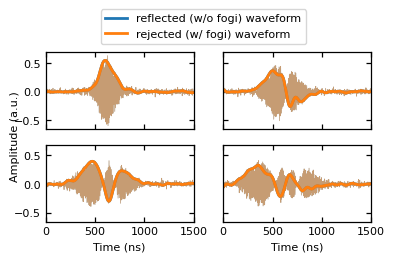

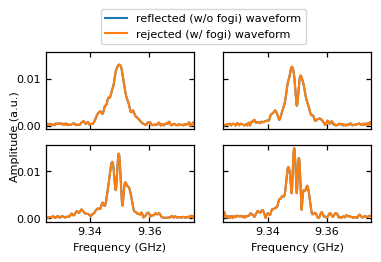

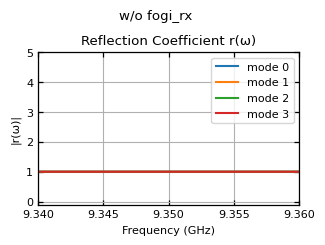

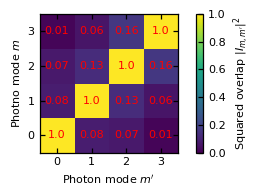

basis_fidelity: 0.944970898500781


In [144]:
result_wo_fogi_dict = {
    "data_sech_0": dict(target_freq=9.35, waveform=acquisition_00, form="sech_0", center=510),
    "data_sech_1": dict(target_freq=9.35, waveform=acquisition_10, form="sech_1", center=480),
    "data_sech_2": dict(target_freq=9.35, waveform=acquisition_20, form="sech_2", center=480),
    "data_sech_3": dict(target_freq=9.35, waveform=acquisition_30, form="sech_3", center=460),
}
analyze_waveforms_t(result_wo_fogi_dict, wofogi=True)
plt.suptitle("w/o fogi_rx", y=1.)

M = 4
expI_matrix = np.zeros((M, M))
I_normalized = np.zeros((M, M))
for m in range(M):
    for m_prime in range(M):
        wf_m = waveform_envelope(globals()[f"acquisition_{m}0"])[2]
        wf_m_prime = waveform_envelope(globals()[f"acquisition_{m_prime}0"])[2]
        expI_matrix[m, m_prime] = overlap(wf_m, wf_m_prime)
        norm_product = np.linalg.norm(wf_m) * np.linalg.norm(wf_m_prime)
        I_normalized[m, m_prime] = expI_matrix[m, m_prime] / norm_product
        
        # plt.plot(wf_m)
        # plt.plot(wf_m_prime)
        # plt.show()

squared_I(np.abs(I_normalized)**2, range(4))
print("basis_fidelity:", basis_fidelity(expI_matrix))
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


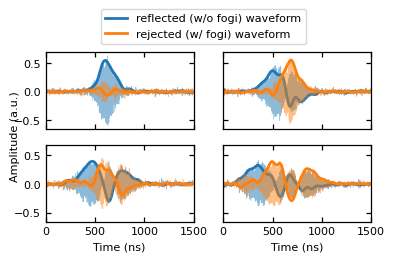

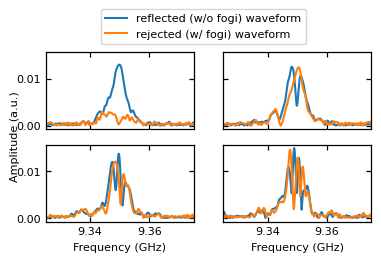

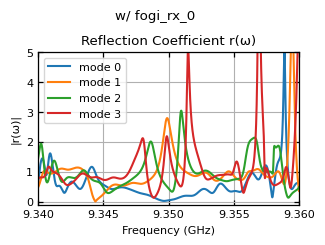

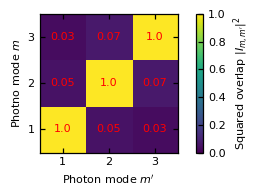

basis_fidelity: 0.9757447539474052


In [146]:
result_w_fogi0_dict = {
    "data_sech_0": dict(target_freq=9.35, waveform=acquisition_00, form="sech_0", center=510),
    "data_sech_1": dict(target_freq=9.35, waveform=acquisition_10, form="sech_1", center=480),
    "data_sech_2": dict(target_freq=9.35, waveform=acquisition_20, form="sech_2", center=480),
    "data_sech_3": dict(target_freq=9.35, waveform=acquisition_30, form="sech_3", center=460),
}
analyze_waveforms_t(result_wo_fogi_dict, wofogi=False)
plt.suptitle("w/ fogi_rx_0", y=1)

selected_indices = [1, 2, 3]
M_sel = len(selected_indices)
expI_matrix_abs0 = np.zeros((M_sel, M_sel))
I_normalized_sel = np.zeros((M_sel, M_sel))

for i, m in enumerate(selected_indices):
    for j, m_prime in enumerate(selected_indices):
        wf_m = waveform_envelope(globals()[f"acquisition_{m}0"])[1]
        wf_m_prime = waveform_envelope(globals()[f"acquisition_{m_prime}0"])[1]
        expI_matrix_abs0[i, j] = overlap(wf_m, wf_m_prime)
        norm_product = np.linalg.norm(wf_m) * np.linalg.norm(wf_m_prime)
        I_normalized_sel[i, j] = expI_matrix_abs0[i, j] / norm_product

squared_I(np.abs(I_normalized_sel)**2, ticks=selected_indices)
print("basis_fidelity:", basis_fidelity(expI_matrix_abs0))

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


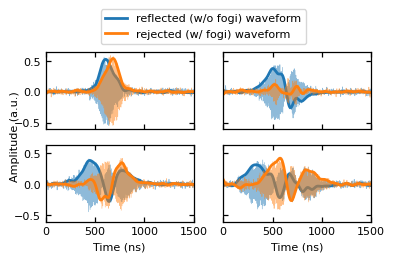

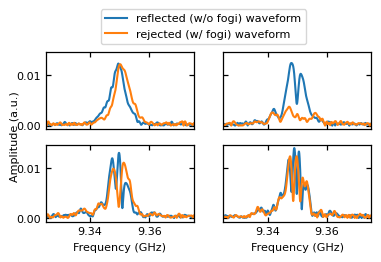

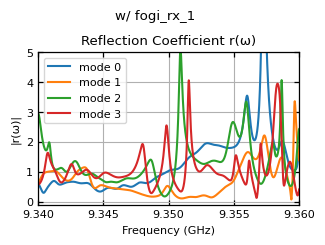

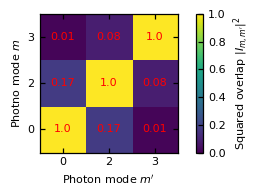

basis_fidelity: 0.9546571703731358


In [152]:
result_w_fogi1_dict = {
    "data_sech_0": dict(target_freq=9.35, waveform=acquisition_01, form="sech_0", center=510),
    "data_sech_1": dict(target_freq=9.35, waveform=acquisition_11, form="sech_1", center=480),
    "data_sech_2": dict(target_freq=9.35, waveform=acquisition_21, form="sech_2", center=480),
    "data_sech_3": dict(target_freq=9.35, waveform=acquisition_31, form="sech_3", center=460),
}
analyze_waveforms_t(result_w_fogi1_dict, wofogi=False)
plt.suptitle("w/ fogi_rx_1", y=1.)

selected_indices = [0, 2, 3]
M_sel = len(selected_indices)
expI_matrix_abs1 = np.zeros((M_sel, M_sel))
I_normalized_sel = np.zeros((M_sel, M_sel))
for i, m in enumerate(selected_indices):
    for j, m_prime in enumerate(selected_indices):
        wf_m = waveform_envelope(globals()[f"acquisition_{m}1"])[1]
        wf_m_prime = waveform_envelope(globals()[f"acquisition_{m_prime}1"])[1]
        expI_matrix_abs1[i, j] = overlap(wf_m, wf_m_prime)
        norm_product = np.linalg.norm(wf_m) * np.linalg.norm(wf_m_prime)
        I_normalized_sel[i, j] = expI_matrix_abs1[i, j] / norm_product
squared_I(np.abs(I_normalized_sel)**2, ticks=selected_indices)
print("basis_fidelity:", basis_fidelity(expI_matrix_abs1))

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


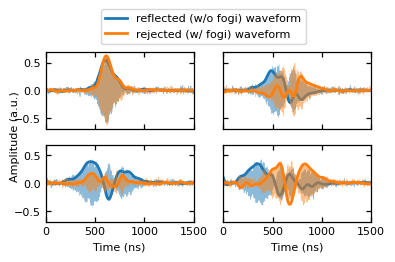

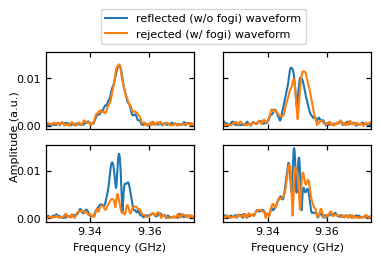

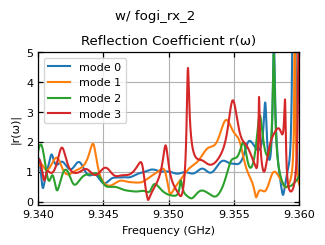

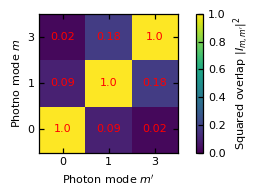

basis_fidelity: 0.9522745257071751


In [151]:
result_w_fogi2_dict = {
    "data_sech_0": dict(target_freq=9.35, waveform=acquisition_02, form="sech_0", center=510),
    "data_sech_1": dict(target_freq=9.35, waveform=acquisition_12, form="sech_1", center=480),
    "data_sech_2": dict(target_freq=9.35, waveform=acquisition_22, form="sech_2", center=480),
    "data_sech_3": dict(target_freq=9.35, waveform=acquisition_32, form="sech_3", center=460),
}
analyze_waveforms_t(result_w_fogi2_dict, wofogi=False)
plt.suptitle("w/ fogi_rx_2", y=1)

selected_indices = [0, 1, 3]
M_sel = len(selected_indices)
expI_matrix_abs2 = np.zeros((M_sel, M_sel))
I_normalized_sel = np.zeros((M_sel, M_sel))

for i, m in enumerate(selected_indices):
    for j, m_prime in enumerate(selected_indices):
        wf_m = waveform_envelope(globals()[f"acquisition_{m}2"])[1]
        wf_m_prime = waveform_envelope(globals()[f"acquisition_{m_prime}2"])[1]
        expI_matrix_abs2[i, j] = overlap(wf_m, wf_m_prime)
        norm_product = np.linalg.norm(wf_m) * np.linalg.norm(wf_m_prime)
        I_normalized_sel[i, j] = expI_matrix_abs2[i, j] / norm_product

squared_I(np.abs(I_normalized_sel)**2, selected_indices)
print("basis_fidelity:", basis_fidelity(expI_matrix_abs2))


d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


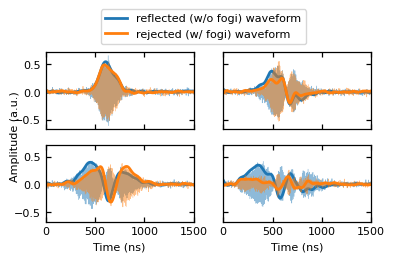

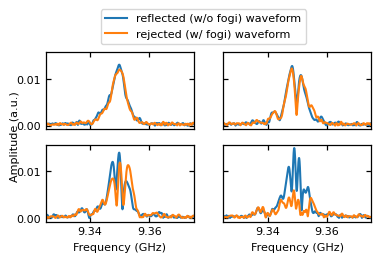

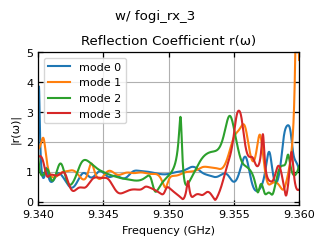

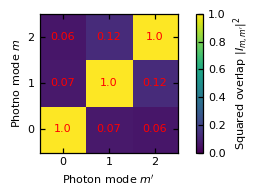

basis_fidelity: 0.9616408142194066


In [150]:
result_w_fogi3_dict = {
    "data_sech_0": dict(target_freq=9.35, waveform=acquisition_03, form="sech_0", center=510),
    "data_sech_1": dict(target_freq=9.35, waveform=acquisition_13, form="sech_1", center=480),
    "data_sech_2": dict(target_freq=9.35, waveform=acquisition_23, form="sech_2", center=480),
    "data_sech_3": dict(target_freq=9.35, waveform=acquisition_33, form="sech_3", center=460),
}
analyze_waveforms_t(result_w_fogi3_dict, wofogi=False)
plt.suptitle("w/ fogi_rx_3", y=1)

selected_indices = [0, 1, 2]
M_sel = len(selected_indices)
expI_matrix_abs3 = np.zeros((M_sel, M_sel))
I_normalized_sel = np.zeros((M_sel, M_sel))

for i, m in enumerate(selected_indices):
    for j, m_prime in enumerate(selected_indices):
        wf_m = waveform_envelope(globals()[f"acquisition_{m}3"])[1]
        wf_m_prime = waveform_envelope(globals()[f"acquisition_{m_prime}3"])[1]
        expI_matrix_abs3[i, j] = overlap(wf_m, wf_m_prime)
        norm_product = np.linalg.norm(wf_m) * np.linalg.norm(wf_m_prime)
        I_normalized_sel[i, j] = expI_matrix_abs3[i, j] / norm_product

squared_I(np.abs(I_normalized_sel)**2, selected_indices)
print("basis_fidelity:", basis_fidelity(expI_matrix_abs3))

scattering matrix

In [52]:
def compute_overlap_between_rejandori(datasets, passing_band= 0.01):
    fig, axes = plt.subplots(2, 2, figsize=(4, 2.2), sharex=True, sharey=True)
    axes = axes.flatten()
    overlaps = []

    for i, (k, v) in enumerate(datasets.items()):
        if i >= 4:
            break

        ax = axes[i]
        target_freq = v["target_freq"]
        readout_lo_freq = 9.47

        time = waveform_complex(acquisition_00)[0]
        waveform_orignal = v["waveform"].get_results()["waveform_zero_fogi"][ph_amp][fogi_freq]
        xfft, fourier = fourier_tr_padding(time, waveform_orignal)
        xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
        phase = np.angle(demodulate(time, waveform_orignal, readout_lo_freq - target_freq))
        lpf = 2 * lowpass(
            time, waveform_orignal * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
            passing_band, 0.03, 0.1, 90
        ) 
        signal_orignal =lpf* np.exp(-1j * phase)
        ax.plot(time, 2000 * waveform_orignal, "tab:blue", lw=0.5, alpha=0.5)
        ax.plot(time, 2000 * signal_orignal, "tab:blue", lw=2, alpha=1)

        waveform_rejected = v["waveform"].get_results()["waveform"][ph_amp][fogi_freq]
        xfft, fourier = fourier_tr_padding(time, waveform_rejected)
        xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
        phase = np.angle(demodulate(time, waveform_rejected, readout_lo_freq - target_freq))
        lpf = 2 * lowpass(
            time, waveform_rejected * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
            passing_band, 0.03, 0.1, 90
        ) 
        signal_rejected =lpf* np.exp(-1j * phase)
        ax.plot(time, 2000 * waveform_rejected, "tab:orange", lw=0.5, alpha=0.5)
        ax.plot(time, 2000 * signal_rejected, "tab:orange", lw=2, alpha=1)

        overlaps.append(overlap(signal_orignal, signal_rejected))

        ax.label_outer()
        ax.set_xlim(0, 1500)
        if i in [2, 3]:
            ax.set_xlabel("Time (ns)")

    # fig.text(0.5, 0.04, "Time (ns)", ha="center")
    fig.text(0.04, 0.5, "Amplitude (a.u.)", va="center", rotation="vertical")
    # fig.legend(handles=handles, loc="upper center", ncol=2)
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
    print(overlaps)
    return overlaps



d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


[7.437545282738456e-07, 1.6646113839687186e-06, 9.80404201387315e-07, 1.474183180058609e-06]
[4.528130896439004e-06, 1.1528260047133016e-06, 1.7337717023283016e-06, 2.070374891103466e-06]
[5.08201580957553e-06, 4.500214865001078e-06, 1.4904664545656222e-06, 2.5888779414128115e-06]
[5.374168280110514e-06, 5.366746586673875e-06, 4.437313749593678e-06, 1.5695860013668675e-06]


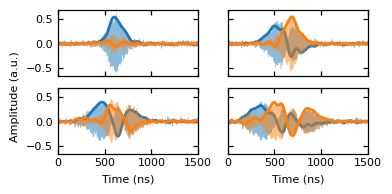

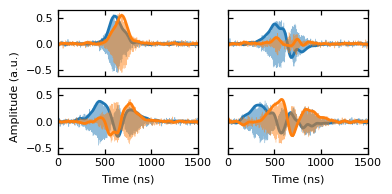

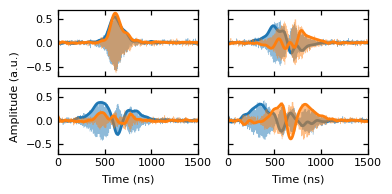

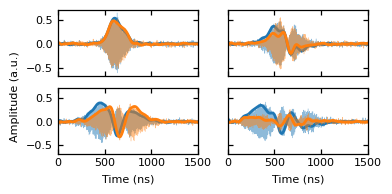

In [53]:
scattering_matrix =[
compute_overlap_between_rejandori(result_w_fogi0_dict),
compute_overlap_between_rejandori(result_w_fogi1_dict),
compute_overlap_between_rejandori(result_w_fogi2_dict),
compute_overlap_between_rejandori(result_w_fogi3_dict)]

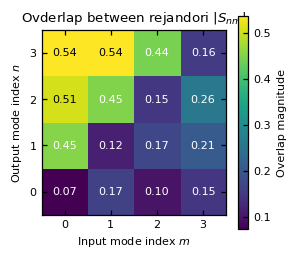

In [55]:
S = np.array(scattering_matrix)*1e5

fig, ax = plt.subplots(figsize=(3, 2.7))

im = ax.imshow(np.abs(S), cmap='viridis', interpolation='nearest', origin='lower')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Overlap magnitude")

ax.set_xlabel("Input mode index $m$")
ax.set_ylabel("Output mode index $n$")
ax.set_title("Ovderlap between rejandori $|S_{nm}|$")

ax.set_xticks(np.arange(S.shape[1]))
ax.set_yticks(np.arange(S.shape[0]))
ax.set_xticklabels([f"{i}" for i in range(S.shape[1])])
ax.set_yticklabels([f"{i}" for i in range(S.shape[0])])

for i in range(S.shape[0]):
    for j in range(S.shape[1]):
        ax.text(j, i, f"{np.abs(S[i, j]):.2f}",
                ha="center", va="center", color="w" if np.abs(S[i, j]) < 0.5 else "black")

plt.tight_layout()
plt.show()

In [ ]:
def compute_and_plot_overlap_matrix(datasets, passing_band=0.01, max_N=4, plot='both', title='No title'):
    keys = list(datasets.keys())[:max_N]
    N = len(keys)
    readout_lo_freq = 9.47
    time = waveform_complex(acquisition_00)[0]

    original_signals = []
    rejected_signals = []

    for k in keys:
        v = datasets[k]
        target_freq = v["target_freq"]

        waveform_o = v["waveform"].get_results()["waveform_zero_fogi"][ph_amp][fogi_freq]
        phase_o = np.angle(demodulate(time, waveform_o, readout_lo_freq - target_freq))
        lpf_o = 2 * lowpass(
            time, waveform_o * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
            passing_band, 0.03, 0.1, 90
        )
        signal_o = lpf_o * np.exp(-1j * phase_o)
        original_signals.append(signal_o)

        waveform_r = v["waveform"].get_results()["waveform"][ph_amp][fogi_freq]
        phase_r = np.angle(demodulate(time, waveform_r, readout_lo_freq - target_freq))
        lpf_r = 2 * lowpass(
            time, waveform_r * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
            passing_band, 0.03, 0.1, 90
        )
        signal_r = lpf_r * np.exp(-1j * phase_r)
        # signal_r = roll_with_interpolation(signal_r, -34)
        rejected_signals.append(signal_r)

    overlaps = np.zeros((N, N), dtype=np.complex128)
    normalized_overlaps =  np.zeros((N, N), dtype=np.complex128)
    for i in range(N):
        for j in range(N):
            overlaps[i, j] = overlap(original_signals[j], rejected_signals[i])
            norm_product = np.linalg.norm(original_signals[j]) * np.linalg.norm(rejected_signals[i])
            normalized_overlaps[i, j] = overlaps[i, j] / norm_product

    if plot in ['grid', 'both']:
        fig, axes = plt.subplots(N, N, figsize=(N*1.2, N*0.9), sharex=True, sharey=True)
        for i in range(N):
            for j in range(N):
                ax = axes[N-1-j, i] if N > 1 else axes
                signal_o = original_signals[i]
                signal_r = rejected_signals[j]
                ov = normalized_overlaps[j, i]

                ax.plot(time, 2000 * signal_o.real, "tab:blue", lw=2, alpha=1, label="Basis (incoming) waveform")
                ax.plot(time, 2000 * signal_r.real, "tab:orange", lw=2, alpha=1, label="Rejected waveform")
                # ax.text(0.05, 0.8, f"|⟨r{j}|o{i}⟩|={abs(ov):.2f}", transform=ax.transAxes, fontsize=8)

                if j == 0:
                    ax.set_xlabel(f"{i}", fontsize=9)
                if i == 0:
                    ax.set_ylabel(f"{j}", fontsize=9)

                ax.set_xlim(0, 1500)
                ax.label_outer()

        fig.text(0.01, 0.5, "Sender mode $m$", va="center", rotation="vertical", fontsize=10)
        fig.text(0.5, 0.01, "Basis mode $l$", ha="center", fontsize=10)
        fig.suptitle(title, fontsize=12)
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize=9, frameon=True, ncol=2, bbox_to_anchor=(1.0, 0.92))
        plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
        plt.show()

    if plot in ['matrix', 'both']:
        fig, ax = plt.subplots(figsize=(N*0.8, N * 0.7))
        squared_I = np.abs(normalized_overlaps)**2
        im = ax.imshow(squared_I, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label(r'Squared overlap $|I_{m, l}|^2$')

        ax.set_xlabel("Basis mode $l$")
        ax.set_ylabel("Sender mode $m$")
        # ax.set_title(title)

        ax.set_xticks(np.arange(N))
        ax.set_yticks(np.arange(N))
        ax.set_xticklabels([f"{i}" for i in range(N)])
        ax.set_yticklabels([f"{i}" for i in range(N)])

        for i in range(N):
            for j in range(N):
                ax.text(j, i, f"{squared_I[i, j]:.2f}",
                        ha="center", va="center", color="red")

        plt.tight_layout()
        plt.show()

    return normalized_overlaps


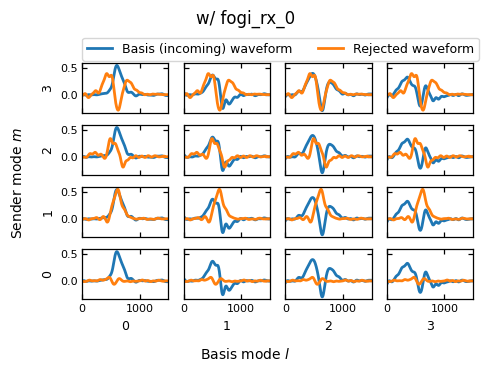

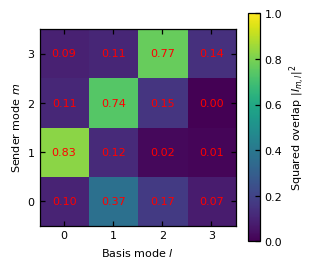

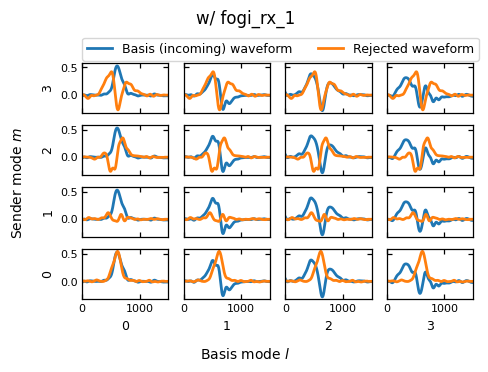

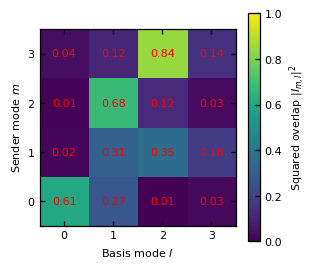

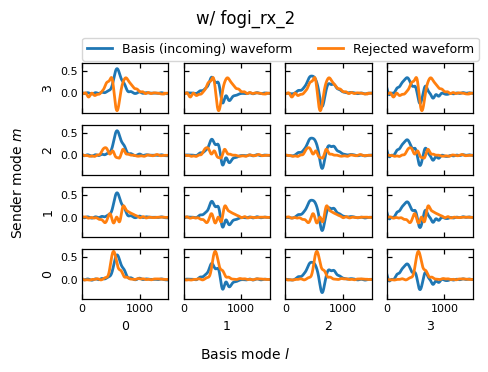

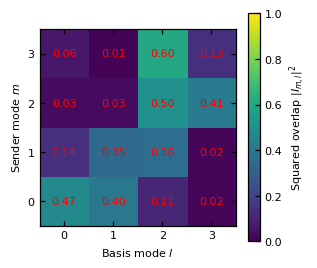

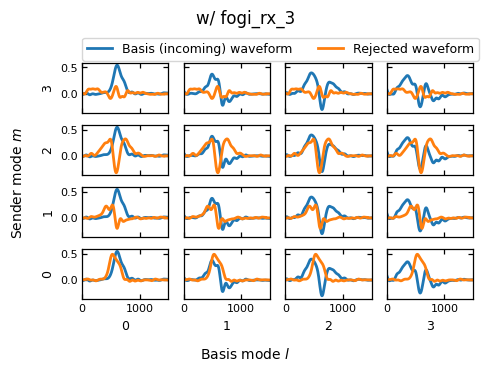

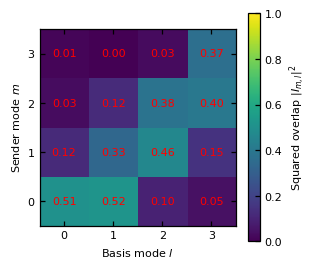

array([[0.71250996+0.j, 0.71897895+0.j, 0.30977218+0.j, 0.21235538+0.j],
       [0.34657557+0.j, 0.57669452+0.j, 0.68147006+0.j, 0.38104195+0.j],
       [0.17743259+0.j, 0.35118977+0.j, 0.61633167+0.j, 0.63282821+0.j],
       [0.11870564+0.j, 0.05139935+0.j, 0.16697974+0.j, 0.60591128+0.j]])

In [127]:
compute_and_plot_overlap_matrix(result_w_fogi0_dict, title="w/ fogi_rx_0")
compute_and_plot_overlap_matrix(result_w_fogi1_dict, title="w/ fogi_rx_1")
compute_and_plot_overlap_matrix(result_w_fogi2_dict, title="w/ fogi_rx_2")
compute_and_plot_overlap_matrix(result_w_fogi3_dict, title="w/ fogi_rx_3")

photon loss rate

In [28]:
# corrected_result_dict_tx = {
#     "data_sech_0": dict(target_freq=9.35, date="2025-02-18", acquire_time="105702", form="sech_0"),
#     "data_sech_1": dict(target_freq=9.35, date="2025-02-18", acquire_time="105752", form="sech_1"),
#     "data_sech_2": dict(target_freq=9.35, date="2025-02-18", acquire_time="105842", form="sech_2"),
#     "data_sech_3": dict(target_freq=9.35, date="2025-02-18", acquire_time="105932", form="sech_3"),
# }

# corrected_result_dict_rx = {
#     "data_sech_0": dict(target_freq=9.35, date="2025-02-18", acquire_time="163203", form="sech_0"),
#     "data_sech_1": dict(target_freq=9.35, date="2025-02-18", acquire_time="163240", form="sech_1"),
#     "data_sech_2": dict(target_freq=9.35, date="2025-02-18", acquire_time="163317", form="sech_2"),
#     "data_sech_3": dict(target_freq=9.35, date="2025-02-18", acquire_time="163355", form="sech_3"),
# }

corrected_result_dict_tx = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-21", acquire_time="105455", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-21", acquire_time="105532", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-21", acquire_time="105609", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-21", acquire_time="105645", form="sech_3"),
}

corrected_result_dict_rx = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-21", acquire_time="103408", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-21", acquire_time="103446", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-21", acquire_time="103522", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-21", acquire_time="103559", form="sech_3"),
} # The energy of these waveforms are too small???

def photon_loss_rate(wave_tx, wave_rx, time):

    ene1 = np.sum(np.abs(wave_tx)**2) * (time[1] - time[0])
    ene2 = np.sum(np.abs(wave_rx)**2) * (time[1] - time[0])
    # plt.plot(np.abs(wave_tx))
    # plt.plot(np.abs(wave_rx))
    # plt.show()
    return ene1/ene2

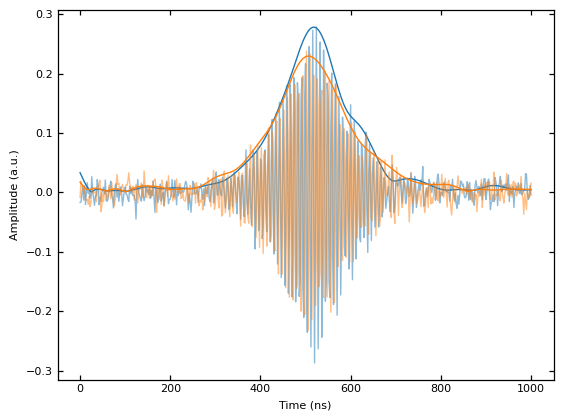

1.2783199263767806


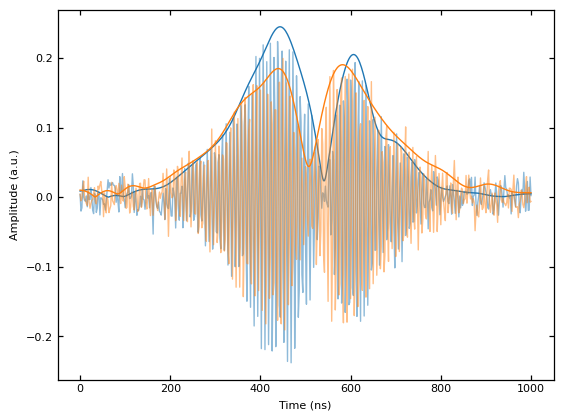

1.211735009006517


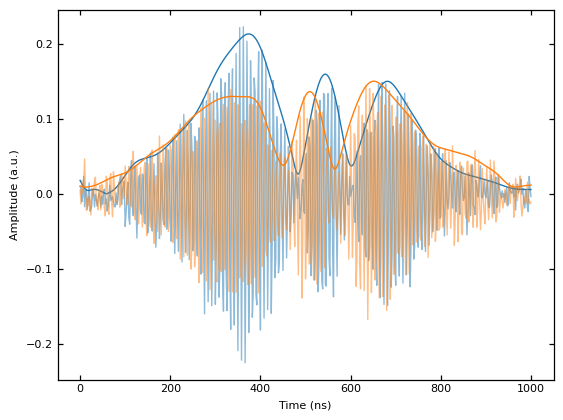

1.3976868226703953


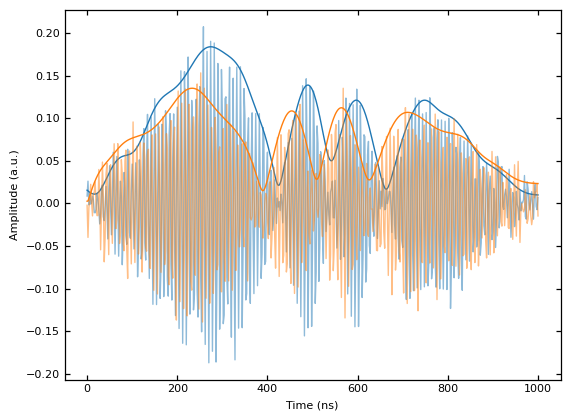

1.5486178495557692


1.3590899019023654

In [29]:
from datataking import search_datadict_miyamura
from Analysis import start_stop, lowpass
data_path = f"D:\\K_Sunada\\result\\{cd}"
readout_lo_freq = 9.47
duration = 1000
passing_band = 0.01
target_freq = 9.35
readout_lo_freq = 9.47
loss_rates = []

for i, ((k1, v1), (k2, v2)) in enumerate(zip(corrected_result_dict_tx.items(), corrected_result_dict_rx.items())):
    _, datadict1 = search_datadict_miyamura(data_path, v1["date"], acquire_time=v1["acquire_time"])
    time1, waveform1 = start_stop(datadict1["time"]["values"].ravel(), datadict1["waveform"]["values"].ravel(), 0, duration)

    _, datadict2 = search_datadict_miyamura(data_path, v2["date"], acquire_time=v2["acquire_time"])
    time2, waveform2 = start_stop(datadict2["time"]["values"].ravel(), datadict2["waveform"]["values"].ravel(), 0, duration)

    phase1 = np.angle(demodulate(time1, waveform1, readout_lo_freq - target_freq))
    signal1 = 2 * lowpass(
        time1, waveform1 * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time1),
        passing_band, 0.03, 0.1, 90
        ) * np.exp(-1j * phase1)
    
    phase2 = np.angle(demodulate(time2, waveform2, readout_lo_freq - target_freq))
    signal2 = 2 * lowpass(
        time2, waveform2 * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time2),
        passing_band, 0.03, 0.1, 90
        ) * np.exp(-1j * phase2)
    
    plt.plot(time1, 1000*np.abs(signal1), "tab:blue")
    plt.plot(time1, 1000*waveform1, "tab:blue", alpha=0.5)
    plt.plot(time2, 1000*np.abs(signal2), "tab:orange")
    plt.plot(time2, 1000*waveform2, "tab:orange", alpha=0.5)
    plt.xlabel("Time (ns)")
    plt.ylabel("Amplitude (a.u.)")
    plt.show()
    r = photon_loss_rate(signal1, signal2, time1)
    loss_rates.append(r)
    print(r)
np.mean(loss_rates)

In [30]:
def calculate_od(squaredI_matrix):
    numerator = 0.0
    for m in range(M):
        for m_prime in range(M):
            expected = 1.0 if m == m_prime else 0.0
            diff = np.sqrt(squaredI_matrix[m, m_prime]) - expected
            numerator += abs(diff)**2

    epsilon = np.sqrt(numerator / (M * (M - 1)))
    return epsilon

In [31]:
calculate_od(squaredI_matrix)

NameError: name 'squaredI_matrix' is not defined